### Day 1

In [3]:
from multiprocessing.reduction import duplicate
from pathlib import Path

from IPython.core.pylabtools import figsize
from PIL import Image
from contourpy import as_z_interp

DATA_DIR = Path("../data/raw")

valid_images = []
invalid_images = []

for class_dir in DATA_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.glob("*.jpg"):
        try:
            with Image.open(image_path) as img:
                img.verify()

            valid_images.append(image_path)

        except Exception as e:
            invalid_images.append((image_path, str(e)))

print(f"Valid images: {len(valid_images)}")
print(f"Invalid images: {len(invalid_images)}")

if invalid_images:
    print("\nInvalid files:")
    for path, error in invalid_images:
        print(path, "->", error)

Valid images: 119
Invalid images: 0


In [4]:
image_properties = []

for class_dir in DATA_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_properties.append({
                "class": class_dir.name,
                "filename": image_path.name,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

print(f"Images inspected: {len(image_properties)}")

Images inspected: 119


In [5]:
from collections import Counter

dimensions = Counter(
    (item["width"], item["height"])
    for item in image_properties
)

modes = Counter(
    item["mode"]
    for item in image_properties
)

print("Unique image dimensions:")
for dimension, count in dimensions.items():
    print(f"{dimensions}: {count}")

print("\nColor modes:")
for mode, count in modes.items():
    print(f"{mode} : {count}")

Unique image dimensions:
Counter({(3081, 897): 85, (250, 200): 2, (766, 250): 1, (617, 244): 1, (1530, 371): 1, (1480, 279): 1, (1504, 323): 1, (765, 224): 1, (763, 268): 1, (699, 197): 1, (456, 124): 1, (316, 127): 1, (427, 193): 1, (768, 514): 1, (296, 88): 1, (286, 92): 1, (340, 94): 1, (467, 104): 1, (359, 168): 1, (311, 170): 1, (1200, 900): 1, (376, 80): 1, (367, 73): 1, (301, 71): 1, (614, 409): 1, (946, 255): 1, (948, 233): 1, (948, 211): 1, (537, 216): 1, (503, 174): 1, (510, 383): 1, (565, 233): 1, (562, 217): 1, (741, 291): 1}): 85
Counter({(3081, 897): 85, (250, 200): 2, (766, 250): 1, (617, 244): 1, (1530, 371): 1, (1480, 279): 1, (1504, 323): 1, (765, 224): 1, (763, 268): 1, (699, 197): 1, (456, 124): 1, (316, 127): 1, (427, 193): 1, (768, 514): 1, (296, 88): 1, (286, 92): 1, (340, 94): 1, (467, 104): 1, (359, 168): 1, (311, 170): 1, (1200, 900): 1, (376, 80): 1, (367, 73): 1, (301, 71): 1, (614, 409): 1, (946, 255): 1, (948, 233): 1, (948, 211): 1, (537, 216): 1, (503, 1

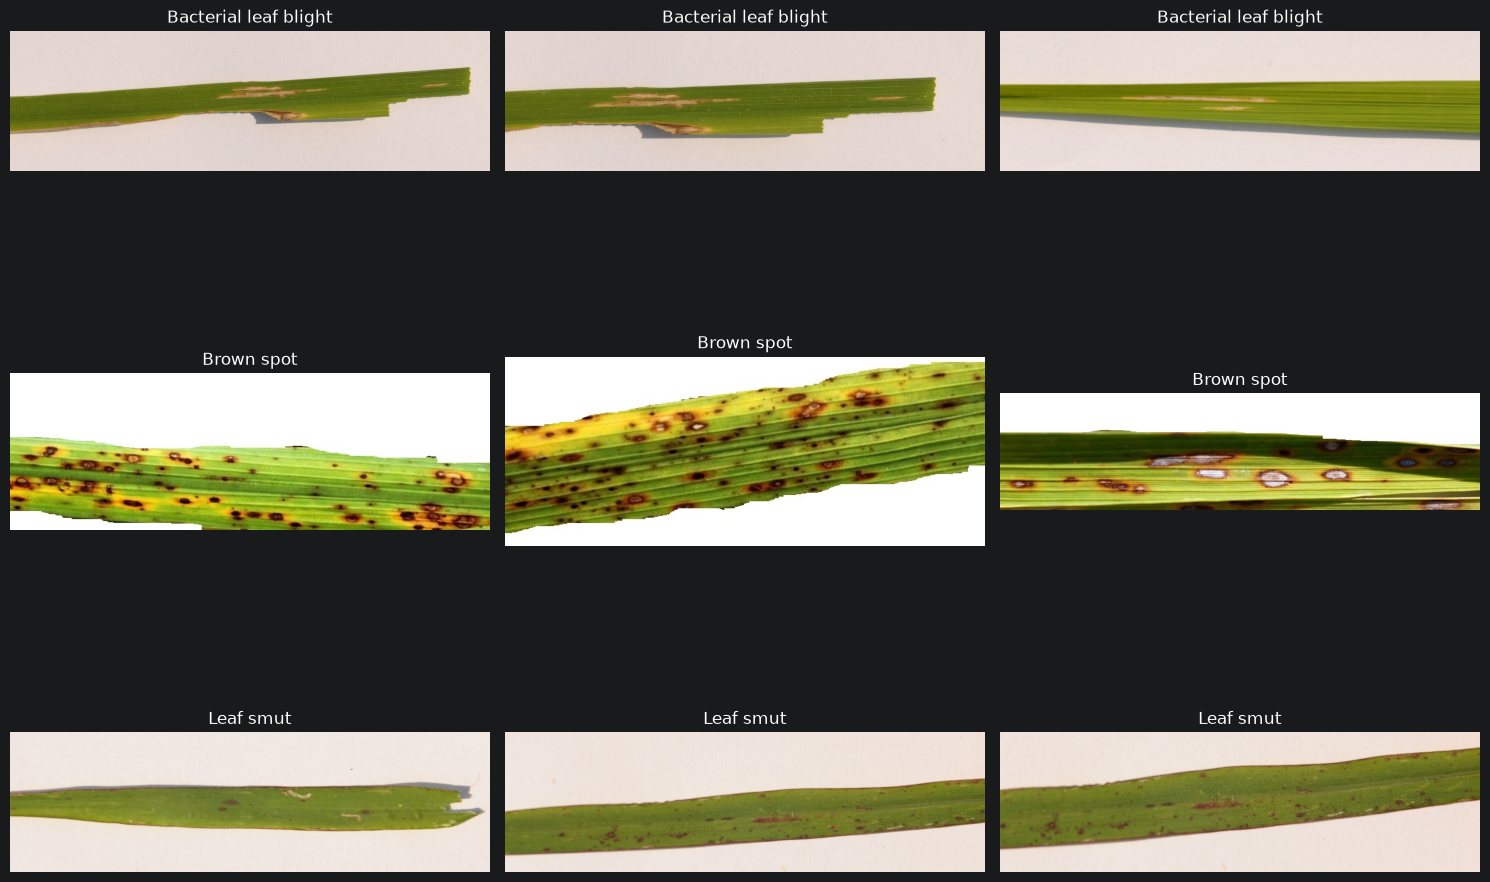

In [8]:
import matplotlib.pyplot as plt
classes = [d for d in DATA_DIR.iterdir() if d.is_dir()]

fig, axes = plt.subplots(3,3, figsize=(15,12))

for row, class_dir in enumerate(classes):
    image_paths = list(class_dir.glob("*.jpg"))[:3]

    for col, image_path in enumerate(image_paths):
        with Image.open(image_path) as img:
            axes[row, col].imshow(img)
            axes[row, col].set_title(class_dir.name)
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [9]:
from collections import Counter

for class_dir in classes:
    class_dimensions = Counter()

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            class_dimensions[(img.width, img.height)] += 1

    print(f"\n{class_dir.name}")
    for dimension, count in class_dimensions.most_common():
        print(f" {dimension}: {count}")


Bacterial leaf blight
 (3081, 897): 40

Brown spot
 (3081, 897): 21
 (766, 250): 1
 (617, 244): 1
 (1530, 371): 1
 (1480, 279): 1
 (1504, 323): 1
 (765, 224): 1
 (763, 268): 1
 (699, 197): 1
 (456, 124): 1
 (316, 127): 1
 (427, 193): 1
 (768, 514): 1
 (296, 88): 1
 (286, 92): 1
 (340, 94): 1
 (467, 104): 1
 (359, 168): 1
 (311, 170): 1
 (1200, 900): 1

Leaf smut
 (3081, 897): 24
 (250, 200): 2
 (376, 80): 1
 (367, 73): 1
 (301, 71): 1
 (614, 409): 1
 (946, 255): 1
 (948, 233): 1
 (948, 211): 1
 (537, 216): 1
 (503, 174): 1
 (510, 383): 1
 (565, 233): 1
 (562, 217): 1
 (741, 291): 1


In [10]:
import matplotlib.pyplot as plt

wide_image = None
normal_image = None

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            if img.size == (3081, 897) and wide_image is None:
                wide_image = image_path

            if img.size == (1200, 900) and normal_image is None:
                normal_image = image_path

        if wide_image is not None and normal_image is not None:
            break
    if wide_image is not None and normal_image is not None:
        break

print("Wide image:", wide_image)
print("Normal image:", normal_image)


Wide image: ..\data\raw\Bacterial leaf blight\DSC_0365.JPG
Normal image: ..\data\raw\Brown spot\DSC_0121.jpg


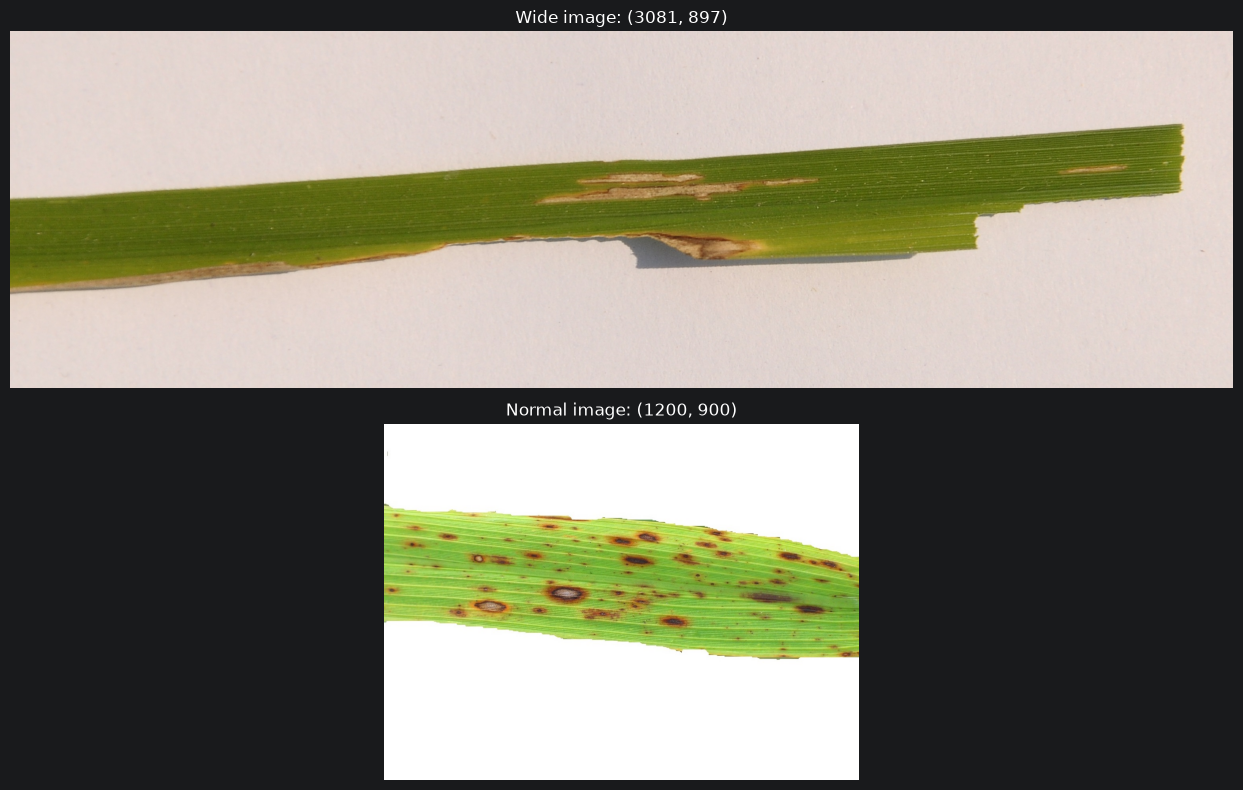

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

with Image.open(wide_image) as img:
    axes[0].imshow(img)
    axes[0].set_title(f"Wide image: {img.size}")
    axes[0].axis("off")

if normal_image is not None:
    with Image.open(normal_image) as img:
        axes[1].imshow(img)
        axes[1].set_title(f"Normal image: {img.size}")
        axes[1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

df = pd.DataFrame(image_properties)

df["aspect_ratio"] = df["width"] / df["height"]

df.groupby("class")["aspect_ratio"].agg(
    ["count", "min", "max", "mean", "median"]
).round(2)

,count,min,max,mean,median
class,,,,,
Bacterial leaf blight,40,3.43,3.43,3.43,3.43
Brown spot,40,1.33,5.30,3.28,3.43
Leaf smut,39,1.25,5.03,3.25,3.43


In [15]:
df[["class", "width", "height", "aspect_ratio"]].sort_values(
    "aspect_ratio", ascending=False
).head(15)

,class,width,height,aspect_ratio
43,Brown spot,1480,279,5.304659
104,Leaf smut,367,73,5.027397
103,Leaf smut,376,80,4.700000
44,Brown spot,1504,323,4.656347
110,Leaf smut,948,211,4.492891
55,Brown spot,467,104,4.490385
105,Leaf smut,301,71,4.239437
42,Brown spot,1530,371,4.123989
109,Leaf smut,948,233,4.068670
108,Leaf smut,946,255,3.709804


In [16]:
import hashlib
from collections import defaultdict

file_hashes = defaultdict(list)

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        file_hashes[file_hash].append(image_path)

duplicates = {
    file_hash: paths
    for file_hash, paths in file_hashes.items()
    if len(paths) > 1
}

print(f"Total files: {len(valid_images)}")
print((f"Unique file contents: {len(file_hashes)}"))
print(f"Duplicate groups: {len(duplicates)}")

for paths in duplicates.values():
    print("\nDuplicate:")
    for path in paths:
        print(" ", path)

Total files: 119
Unique file contents: 119
Duplicate groups: 0


In [17]:
import numpy as np
from PIL import ImageOps

def image_signature(image_path, size=(32, 32)):
    with Image.open(image_path) as img:
        img = img.convert("RGB")

        # Preserve aspect ratio while fitting into a fixed canvas
        img = ImageOps.contain(img, size)

        canvas = Image.new("RGB", size, "white")

        x = (size[0] - img.width) // 2
        y = (size[1] - img.height) // 2

        canvas.paste(img, (x,y))

        arr = np.asarray(canvas, dtype=np.float32)

        # Normalize brightness so comparison focuses less on exposure
        arr = arr / 255.0

        return arr

In [18]:
image_paths = [
    path
    for class_dir in classes
    for path in class_dir.glob("*.jpg")
]

signatures = {
    path: image_signature(path)
    for path in image_paths
}

In [19]:
similar_pairs = []

for i in range(len(image_paths)):
    for j in range(i + 1, len(image_paths)):
        path1 = image_paths[i]
        path2 = image_paths[j]

        diff = np.mean(np.abs(signatures[path1] - signatures[path2]))

        similar_pairs.append((diff, path1, path2))

similar_pairs.sort(key=lambda x: x[0])

for diff, path1, path2 in similar_pairs[:15]:
    print(f"{diff:.4f} | {path1} | {path2}")

0.0074 | ..\data\raw\Leaf smut\DSC_0504.jpg | ..\data\raw\Leaf smut\DSC_0512.jpg
0.0103 | ..\data\raw\Leaf smut\DSC_0322.jpg | ..\data\raw\Leaf smut\DSC_0335.JPG
0.0109 | ..\data\raw\Bacterial leaf blight\DSC_0367.JPG | ..\data\raw\Bacterial leaf blight\DSC_0382.JPG
0.0111 | ..\data\raw\Leaf smut\DSC_0310.JPG | ..\data\raw\Leaf smut\DSC_0321.JPG
0.0114 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Leaf smut\DSC_0316.JPG
0.0114 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Brown spot\DSC_0307.JPG
0.0117 | ..\data\raw\Bacterial leaf blight\DSC_0390.JPG | ..\data\raw\Bacterial leaf blight\DSC_0396.JPG
0.0118 | ..\data\raw\Brown spot\DSC_0300.JPG | ..\data\raw\Leaf smut\DSC_0322.jpg
0.0118 | ..\data\raw\Leaf smut\DSC_0317.JPG | ..\data\raw\Leaf smut\DSC_0319.jpg
0.0121 | ..\data\raw\Leaf smut\DSC_0310.JPG | ..\data\raw\Leaf smut\DSC_0335.JPG
0.0121 | ..\data\raw\Bacterial leaf blight\DSC_0375.JPG | ..\data\raw\Bacterial leaf blight\DSC_0376.JPG
0.0124 | ..\data\raw\Brown spot\D

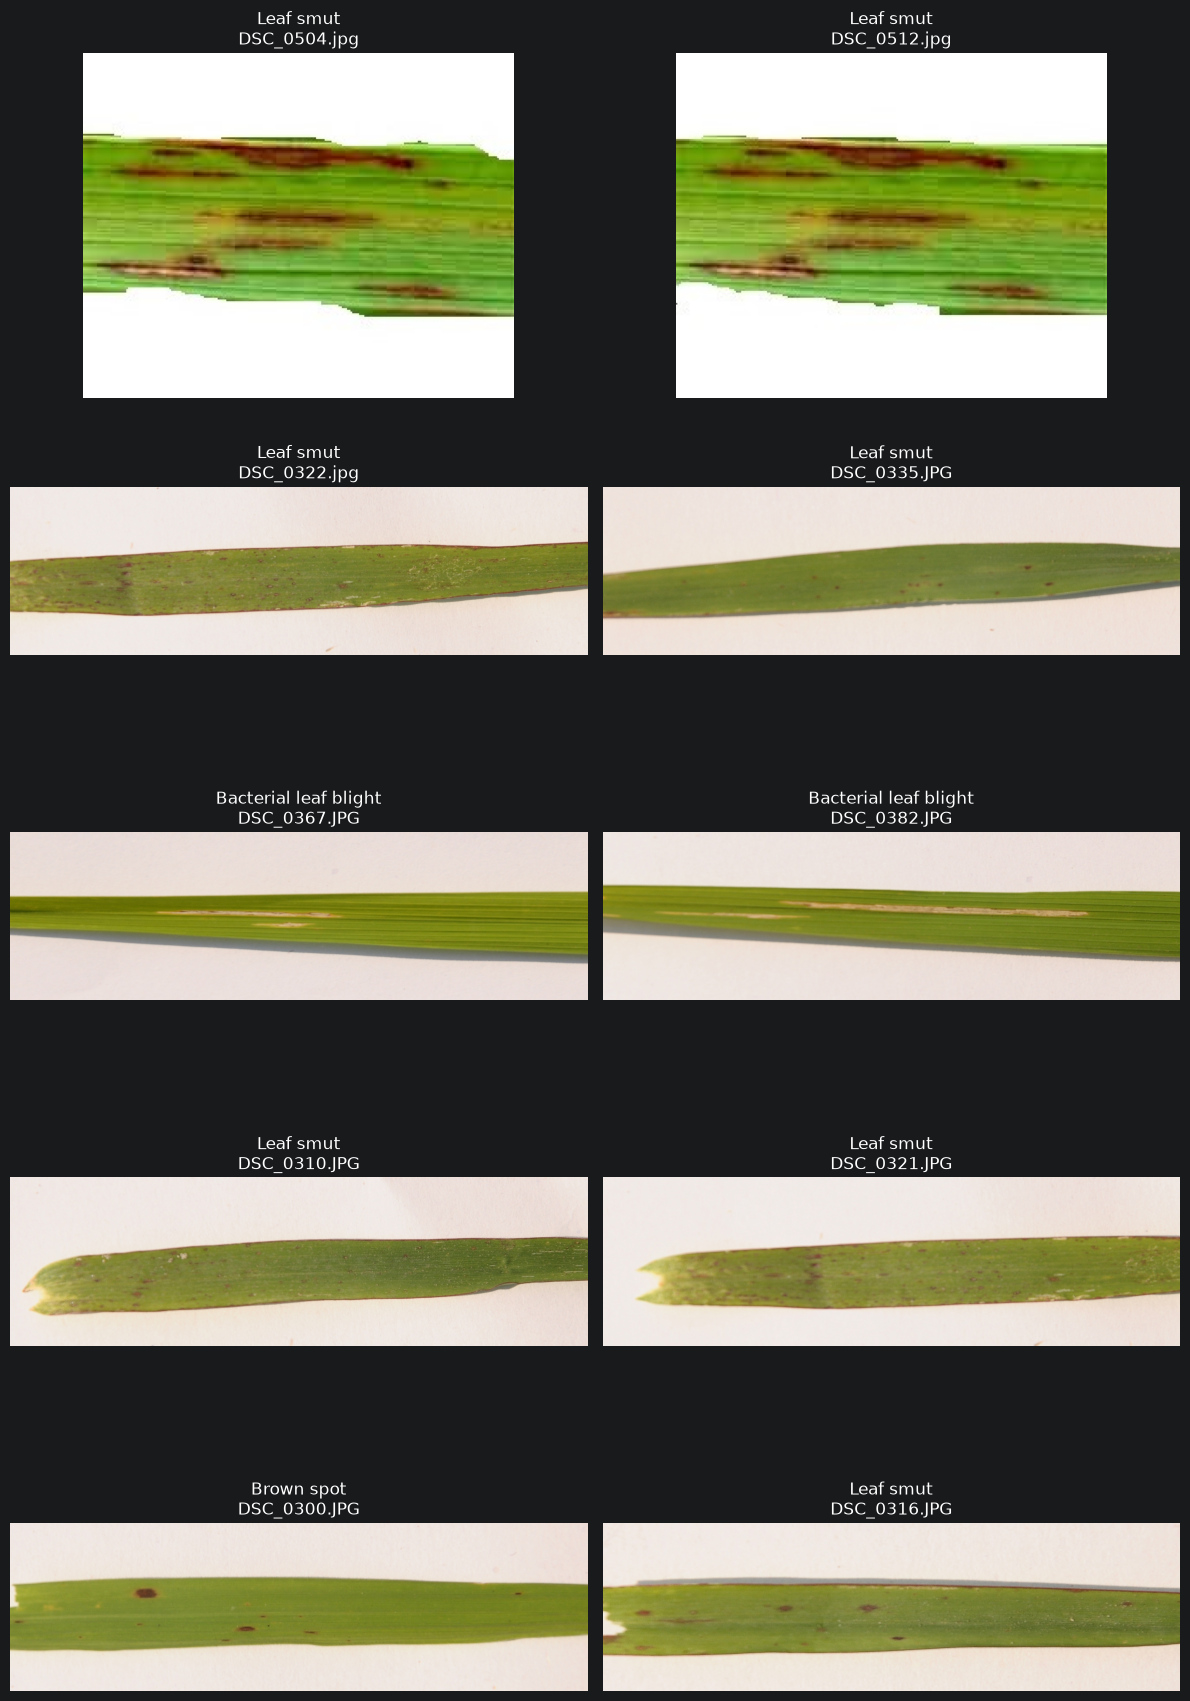

In [20]:
import matplotlib.pyplot as plt

top_pairs = similar_pairs[:5]

fig, axes = plt.subplots(len(top_pairs), 2, figsize=(12, 18))

for row, (diff, path1, path2) in enumerate(top_pairs):

    with Image.open(path1) as img1:
        axes[row, 0].imshow(img1)
        axes[row, 0].set_title(
            f"{path1.parent.name}\n{path1.name}"
        )
        axes[row, 0].axis("off")

    with Image.open(path2) as img2:
        axes[row, 1].imshow(img2)
        axes[row, 1].set_title(
            f"{path2.parent.name}\n{path2.name}"
        )
        axes[row, 1].axis("off")

    axes[row, 0].set_ylabel(f"diff = {diff:.4f}", rotation=90)

plt.tight_layout()
plt.show()

In [21]:
class_counts = df["class"].value_counts()

print(class_counts)

class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64


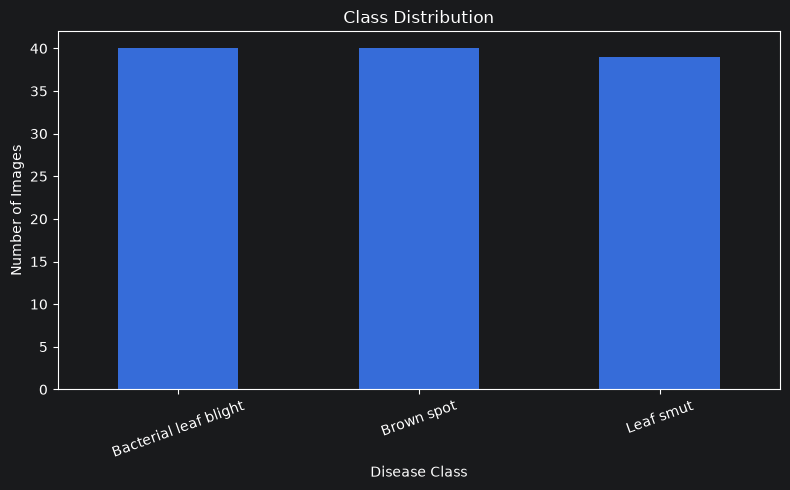

In [23]:
class_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

quality_records = []

for class_dir in classes:
    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            img_array = np.asarray(img.convert("RGB"), dtype=np.float32)

            mean_brightness = img_array.mean()
            min_pixel = img_array.min()
            max_pixel = img_array.max()

            quality_records.append({
                "class": class_dir.name,
                "filename": image_path.name,
                "mean_brightness": mean_brightness,
                "min_pixel": min_pixel,
                "max_pixel": max_pixel
            })

quality_df =pd.DataFrame(quality_records)

print("Brightness summary:")
print(quality_df["mean_brightness"].describe().round(2))

Brightness summary:
count    119.00
mean     171.83
std       28.08
min       75.94
25%      161.59
50%      179.46
75%      188.10
max      231.25
Name: mean_brightness, dtype: float64


In [25]:
print("\nDarkest images:")
print(
    quality_df.sort_values("mean_brightness")
    [["class", "filename", "mean_brightness"]].head(5)
)

print("\nBrightest images:")
print(
    quality_df.sort_values("mean_brightness", ascending=False)
    [["class", "filename", "mean_brightness"]].head(5)
)


Darkest images:
          class      filename  mean_brightness
116   Leaf smut  DSC_0514.jpg        75.942978
117   Leaf smut  DSC_0515.jpg        87.945557
118   Leaf smut  DSC_0516.jpg        88.707428
112   Leaf smut  DSC_0510.jpg        93.825142
55   Brown spot  DSC_0117.jpg       106.379578

Brightest images:
                     class      filename  mean_brightness
111              Leaf smut  DSC_0509.jpg       231.247406
37   Bacterial leaf blight  DSC_0701.jpg       231.195328
51              Brown spot  DSC_0113.jpg       216.100189
58              Brown spot  DSC_0121.jpg       214.410126
86               Leaf smut  DSC_0314.JPG       214.123184


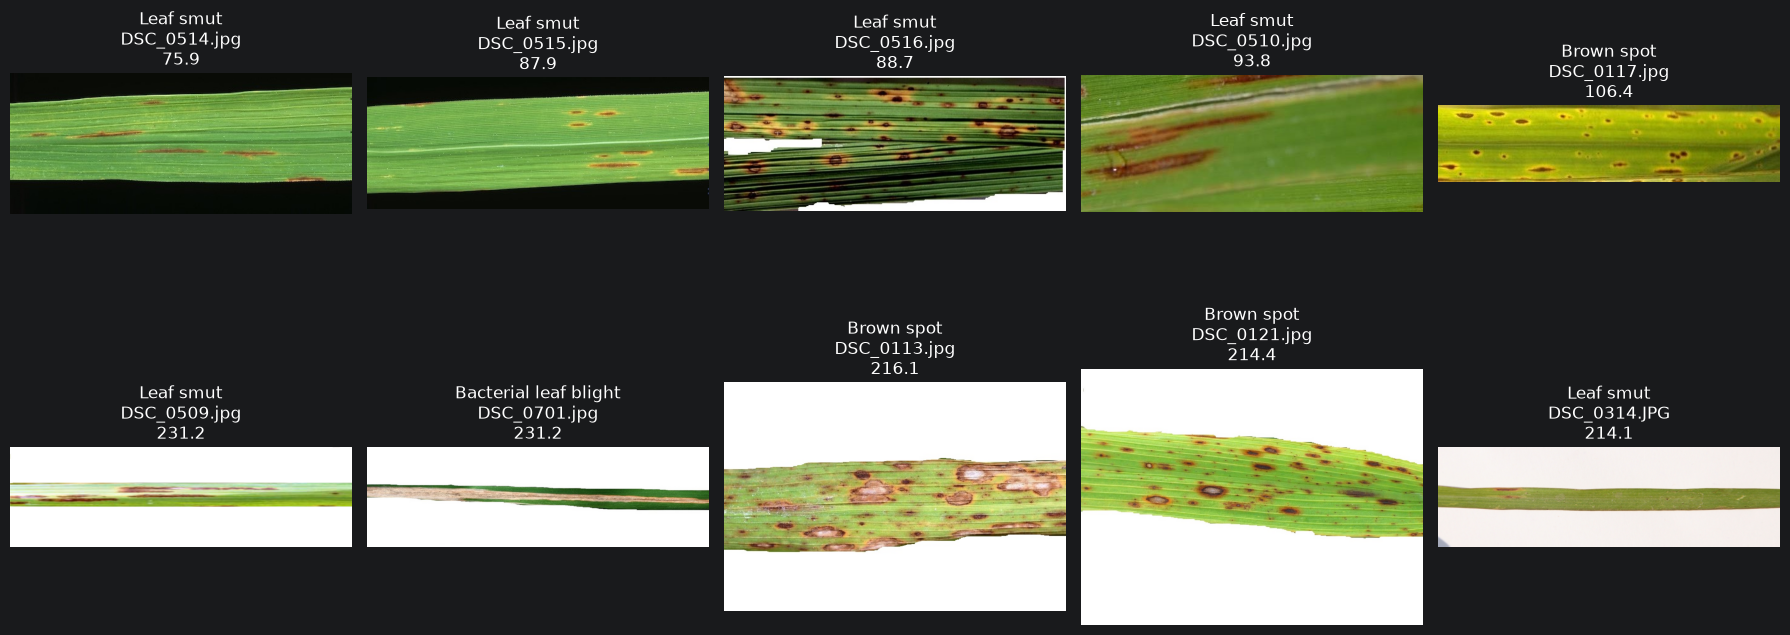

In [26]:
darkest = quality_df.nsmallest(5, "mean_brightness")
brightest = quality_df.nlargest(5, "mean_brightness")

extreme_images = pd.concat([darkest, brightest])

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for col, (_, row) in enumerate(darkest.iterrows()):
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        axes[0, col].imshow(img)
        axes[0, col].set_title(
            f"{row['class']}\n{row['filename']}\n{row['mean_brightness']:.1f}"
        )
        axes[0, col].axis("off")

for col, (_, row) in enumerate(brightest.iterrows()):
    image_path = DATA_DIR / row["class"] / row["filename"]

    with Image.open(image_path) as img:
        axes[1, col].imshow(img)
        axes[1, col].set_title(
            f"{row['class']}\n{row['filename']}\n{row['mean_brightness']:.1f}"
        )
        axes[1, col].axis("off")

axes[0, 0].set_ylabel("Darkest")
axes[1, 0].set_ylabel("Brightest")

plt.tight_layout()
plt.show()